### MOMM PROJECT


## 🌐 **Google Drive Connection**

In [1]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My\\ Drive//MolModMaterialsProject/MMOM-project"
%cd $current_dir

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
/gdrive/.shortcut-targets-by-id/1uZqswhjcH6gS_oh_gpImFaor6s5NAeCJ/MolModMaterialsProject/MMOM-project


## ⚙️ **Libraries Import**

In [2]:
!pip install numba-progress
!pip install torchsummary
!pip install tensorboard
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.mps.manual_seed(SEED)
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from numba import njit, prange
from scipy.spatial import cKDTree
from tqdm.auto import tqdm

logs_dir = "networks"

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

Looking in indexes: https://download.pytorch.org/whl/cu118
PyTorch version: 2.11.0+cu128
Device: cuda


## 🐱 **Hyperparameters**

In [3]:
BATCH_SIZE=256

# Model architecture configuration
HIDDEN_LAYERS = 3
HIDDEN_SIZE = 256
DROPOUT_RATE = 0.0

LEARNING_RATE = 1e-3
EPOCHS = 1500
PATIENCE = 75
L2_LAMBDA = 0.0


## ⏳ **Data Loading**

In [4]:
symmetry_dataset_path = 'lammps/silicon_symmetry_dataset_try.csv'
extracted_data_path = 'lammps/extracted_data.csv'
generate = True

# Set file_path based on existence of the symmetry dataset
if os.path.exists(symmetry_dataset_path):
    file_path = symmetry_dataset_path
    generate = False
    print(f"Using augmented dataset: {file_path}")
else:
    file_path = extracted_data_path
    print(f"Augmented dataset not found. Using original data: {file_path}")

data = pd.read_csv(file_path, engine='pyarrow')

# Display the first few rows of the data
display(data.head())

Augmented dataset not found. Using original data: lammps/extracted_data.csv


,timestep,box_x,box_y,box_z,atom_id,x,y,z,fx,fy,fz,pe_atom
0,0,16.293,16.293,16.293,1,0.00000,0.00000,0.00000,4.714760e-15,4.714820e-15,4.714760e-15,-4.3366
1,0,16.293,16.293,16.293,2,0.00000,2.71550,2.71550,7.896600e-15,-4.790280e-16,-4.790280e-16,-4.3366
2,0,16.293,16.293,16.293,3,2.71550,0.00000,2.71550,-4.790350e-16,7.896620e-15,-4.790580e-16,-4.3366
3,0,16.293,16.293,16.293,4,2.71550,2.71550,0.00000,-4.790550e-16,-4.790550e-16,7.896570e-15,-4.3366
4,0,16.293,16.293,16.293,5,1.35775,1.35775,1.35775,-6.325530e-25,0.000000e+00,-2.524350e-28,-4.3366


## 🔎 **Exploration and Data Analysis**

In [5]:
# Assign the loaded data to silicon_dataset
silicon_dataset = data
print('Silicon dataset shape:', silicon_dataset.shape)

# Display the first 10 rows of the dataset
silicon_dataset.head(10)

Silicon dataset shape: (1944216, 12)


,timestep,box_x,box_y,box_z,atom_id,x,y,z,fx,fy,fz,pe_atom
0,0,16.293,16.293,16.293,1,0.00000,0.00000,0.00000,4.714760e-15,4.714820e-15,4.714760e-15,-4.3366
1,0,16.293,16.293,16.293,2,0.00000,2.71550,2.71550,7.896600e-15,-4.790280e-16,-4.790280e-16,-4.3366
2,0,16.293,16.293,16.293,3,2.71550,0.00000,2.71550,-4.790350e-16,7.896620e-15,-4.790580e-16,-4.3366
3,0,16.293,16.293,16.293,4,2.71550,2.71550,0.00000,-4.790550e-16,-4.790550e-16,7.896570e-15,-4.3366
4,0,16.293,16.293,16.293,5,1.35775,1.35775,1.35775,-6.325530e-25,0.000000e+00,-2.524350e-28,-4.3366
5,0,16.293,16.293,16.293,6,1.35775,4.07325,4.07325,-2.144900e-15,3.174760e-15,3.174820e-15,-4.3366
6,0,16.293,16.293,16.293,7,4.07325,1.35775,4.07325,3.174790e-15,-2.144920e-15,3.174820e-15,-4.3366
7,0,16.293,16.293,16.293,8,4.07325,4.07325,1.35775,3.174820e-15,3.174790e-15,-2.144870e-15,-4.3366
8,0,16.293,16.293,16.293,9,5.43100,0.00000,0.00000,-1.036920e-15,7.003350e-15,7.003350e-15,-4.3366
9,0,16.293,16.293,16.293,10,5.43100,2.71550,2.71550,2.097030e-15,-2.695770e-15,-2.695740e-15,-4.3366


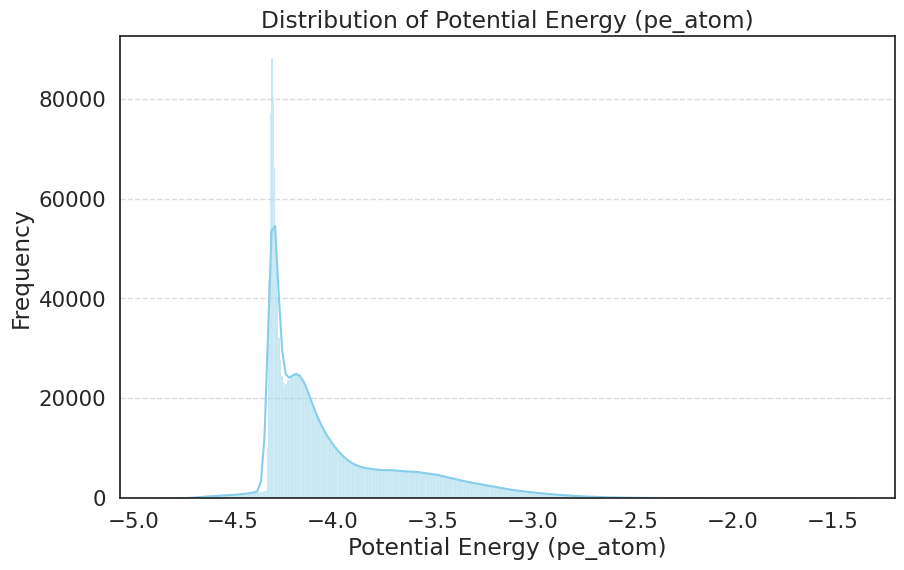

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(silicon_dataset['pe_atom'], kde=True, color='skyblue')
plt.title('Distribution of Potential Energy (pe_atom)')
plt.xlabel('Potential Energy (pe_atom)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [7]:
# Check for missing values in each column
missing_values = silicon_dataset.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
timestep    0
box_x       0
box_y       0
box_z       0
atom_id     0
x           0
y           0
z           0
fx          0
fy          0
fz          0
pe_atom     0
dtype: int64


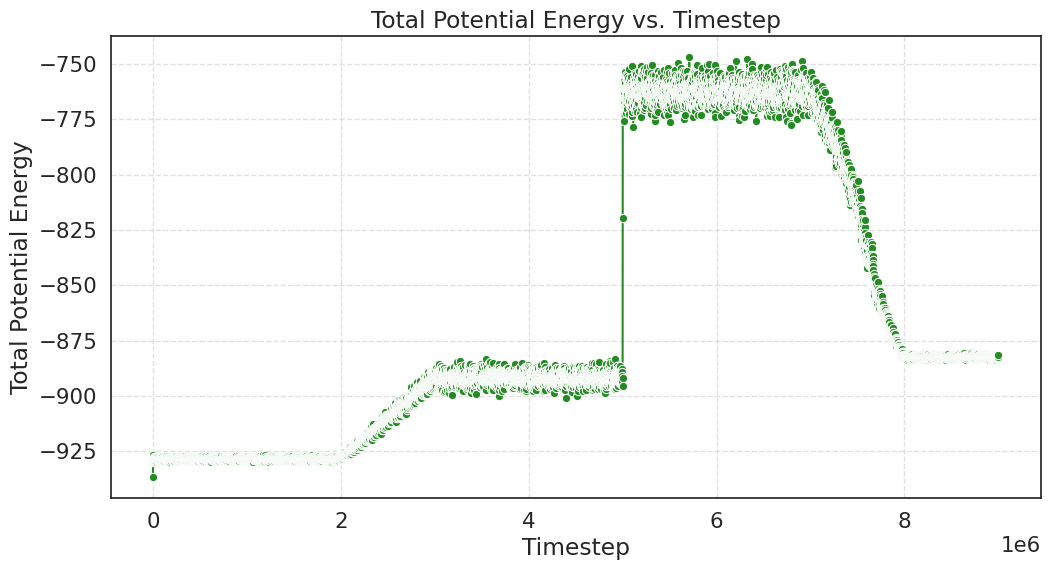

In [8]:
# Group by timestep and sum the potential energy of all atoms to get total energy
total_energy_per_step = silicon_dataset.groupby('timestep')['pe_atom'].sum().reset_index()

# Plot Total Energy vs Timestep
plt.figure(figsize=(12, 6))
sns.lineplot(data=total_energy_per_step, x='timestep', y='pe_atom', marker='o', color='forestgreen')
plt.title('Total Potential Energy vs. Timestep')
plt.xlabel('Timestep')
plt.ylabel('Total Potential Energy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 🫪 **Converting Function**

In [9]:
@njit(parallel=True, fastmath=True)
def compute_symmetry_functions(coords_3d, eta_rad, eta_ang, Rc, Rs, lmbda, zeta):
    """
    Computes G1 and G2 symmetry functions for each atom in each frame.

    Parameters:
    - coords_3d:     (num_frames, num_atoms, 3) array of coordinates.
    - eta_rad:  1-D array of eta values for radial (G1) functions.
    - eta_ang:  1-D array of eta values for angular (G2) functions.
    - Rc:            cutoff radius.
    - Rs:            1-D array of radial shift values.
    - lmbda:         1-D array of lambda values for angular functions.
    - zeta:          1-D array of zeta values for angular functions.

    Feature layout in the output:
      [0 … n_eta_rad*n_Rs)              → G1 radial,  ordered as (eta_rad, Rs)
      [n_eta_rad*n_Rs … total)          → G2 angular, ordered as (eta_ang, zeta, lmbda)
    """
    num_frames = coords_3d.shape[0]
    num_atoms  = coords_3d.shape[1]

    n_eta_rad = len(eta_rad)
    n_Rs      = len(Rs)
    n_eta_ang = len(eta_ang)
    n_zeta    = len(zeta)
    n_lmbda   = len(lmbda)

    num_radial   = n_eta_rad * n_Rs
    num_angular  = n_eta_ang * n_zeta * n_lmbda
    num_sf       = num_radial + num_angular

    fingerprints = np.zeros((num_frames, num_atoms, num_sf), dtype=np.float64)

    for f in prange(num_frames):
        frame_coords = coords_3d[f]

        for i in range(num_atoms):
            xi, yi, zi = frame_coords[i, 0], frame_coords[i, 1], frame_coords[i, 2]

            for j in range(num_atoms):
                if i == j:
                    continue

                xj, yj, zj = frame_coords[j, 0], frame_coords[j, 1], frame_coords[j, 2]
                dx_ij = xi - xj
                dy_ij = yi - yj
                dz_ij = zi - zj
                rij = np.sqrt(dx_ij**2 + dy_ij**2 + dz_ij**2)

                if rij >= Rc:
                    continue

                cut_ij = 0.5 * (np.cos(np.pi * rij / Rc) + 1.0)

                # ── G1 radial: loop over all (eta_rad, Rs) pairs ──────────────
                for e_idx in range(n_eta_rad):
                    eta_r = eta_rad[e_idx]
                    for p in range(n_Rs):
                        rad_idx = e_idx * n_Rs + p
                        fingerprints[f, i, rad_idx] += (
                            np.exp(-eta_r * (rij - Rs[p]) ** 2) * cut_ij
                        )

                # ── G2 angular: loop over k neighbours ───────────────────────
                for k in range(num_atoms):
                    if k == i or k == j:
                        continue

                    xk, yk, zk = frame_coords[k, 0], frame_coords[k, 1], frame_coords[k, 2]
                    dx_ik = xi - xk
                    dy_ik = yi - yk
                    dz_ik = zi - zk
                    rik = np.sqrt(dx_ik**2 + dy_ik**2 + dz_ik**2)

                    if rik >= Rc:
                        continue

                    dx_jk = xj - xk
                    dy_jk = yj - yk
                    dz_jk = zj - zk
                    rjk = np.sqrt(dx_jk**2 + dy_jk**2 + dz_jk**2)

                    if rjk >= Rc:
                        continue

                    cut_ik = 0.5 * (np.cos(np.pi * rik / Rc) + 1.0)
                    cut_jk = 0.5 * (np.cos(np.pi * rjk / Rc) + 1.0)

                    dot_product  = dx_ij * dx_ik + dy_ij * dy_ik + dz_ij * dz_ik
                    cos_theta    = dot_product / (rij * rik)
                    r2_sum       = rij ** 2 + rik ** 2 + rjk ** 2

                    # loop over all (eta_ang, zeta, lmbda) combinations
                    for ea_idx in range(n_eta_ang):
                        exp_term = np.exp(-eta_ang[ea_idx] * r2_sum)

                        for z_idx in range(n_zeta):
                            for l_idx in range(n_lmbda):
                                ang_idx = (
                                    num_radial
                                    + ea_idx * n_zeta * n_lmbda
                                    + z_idx  * n_lmbda
                                    + l_idx
                                )
                                fingerprints[f, i, ang_idx] += 2**(1 - zeta[z_idx]) * (
                                    (1.0 + lmbda[l_idx] * cos_theta) ** zeta[z_idx]
                                    * exp_term * cut_ij * cut_ik * cut_jk
                                )

    return fingerprints

In [ ]:
# Define hyperparameters for the Behler-Parrinello symmetry functions
if generate==True:
    Rc_val = 7.0
    eta_radial = np.array([0.05, 0.5, 1.0, 5.0])
    Rs_grid = np.linspace(0, Rc_val, num=8)

    eta_angular = np.array([0.01, 0.05, 0.1, 0.5])
    lambda_grid = np.array([1.0, -1.0])
    zeta_grid = np.array([1.0, 2.0, 4.0, 8.0, 16.0])

    # Determine the number of unique atoms per frame to guide reshaping
    atoms_per_frame = len(np.unique(silicon_dataset['atom_id']))

    # Extract x, y, z coordinates and reshape into a 3D array (frames, atoms, 3 coordinates)
    coords_flat = silicon_dataset[['x', 'y', 'z']].values
    coords_3d = coords_flat.reshape(-1, atoms_per_frame, 3)
    n_frames = coords_3d.shape[0]

    print(f"Found {n_frames} frame of {atoms_per_frame} atoms each.")

    batch_size = 1 #just to let us use the bar
    risultati_list = []

    for i in tqdm(range(0, n_frames, batch_size), desc="Calcolo funzioni di simmetria"):
        batch_coords = coords_3d[i : i + batch_size]

        batch_res = compute_symmetry_functions(
            coords_3d=batch_coords,
            Rc=Rc_val,
            eta_rad=eta_radial,
            Rs=Rs_grid,
            eta_ang=eta_angular,
            zeta=zeta_grid,
            lmbda=lambda_grid
        )
        risultati_list.append(batch_res)

    risultati_3d = np.vstack(risultati_list)
    print("Computation completed! Formatting the dataframe...")

    # Reshape the symmetry functions to match the original dataset structure
    num_symmetry_functions = risultati_3d.shape[2]
    symmetry_flat = risultati_3d.reshape(-1, num_symmetry_functions)

    # Create column names for symmetry functions
    num_radial = len(eta_radial) * len(Rs_grid)   # 48
    num_angular = len(eta_angular) * len(zeta_grid) * len(lambda_grid)  # 48
    symmetry_cols = [f'sf_{i}' for i in range(num_symmetry_functions)]

    # Create a dataframe with symmetry functions
    symmetry_df = pd.DataFrame(symmetry_flat, columns=symmetry_cols)

    # Split into G1 (radial) and G2 (angular)
    g1_cols = symmetry_cols[:num_radial]
    g2_cols = symmetry_cols[num_radial:]

    g1_df = symmetry_df[g1_cols].copy()
    g2_df = symmetry_df[g2_cols].copy()

    # Rename columns for clarity
    g1_df.columns = [f'g1_{i}' for i in range(len(g1_df.columns))]
    g2_df.columns = [f'g2_{i}' for i in range(len(g2_df.columns))]

    silicon_symmetry = pd.concat([g1_df, g2_df], axis=1)

    # Concatenate with the original dataset
    silicon_dataset = pd.concat([silicon_dataset.reset_index(drop=True), g1_df, g2_df], axis=1)

    print(f"Symmetry functions added! G1:{g1_df.shape[1]} G2:{g2_df.shape[1]} Dataset shape: {silicon_dataset.shape}")
    print(silicon_dataset.head())

    silicon_dataset.to_csv(symmetry_dataset_path, index=False)

Found 9001 frame of 216 atoms each.


Calcolo funzioni di simmetria:   0%|          | 0/9001 [00:00<?, ?it/s]

## 🔄 **Data Preprocessing**

In [ ]:
# # Identify symmetry function columns (g1_0...g1_5 and g2_0...g2_7)
# symmetry_columns = [col for col in silicon_dataset.columns if col.startswith('g1_') or col.startswith('g2_')]

# X = silicon_dataset[symmetry_columns]
# y = silicon_dataset['pe_atom']

# X_train_val, X_test, y_train_val, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.1,
#     random_state=SEED
# )

# # Second split: divide remaining data into training and validation sets
# X_train, X_val, y_train, y_val = train_test_split(
#     X_train_val,
#     y_train_val,
#     test_size=0.09,
#     random_state=SEED
# )

# # Show final dataset sizes
# print(f'Selected {len(symmetry_columns)} symmetry function features.')
# print('Training set shape:\t', X_train.shape, y_train.shape)
# print('Validation set shape:\t', X_val.shape, y_val.shape)
# print('Test set shape:\t\t', X_test.shape, y_test.shape)

In [ ]:
# 1. Get an array of all unique frames (timesteps)
all_timesteps = np.sort(silicon_dataset['timestep'].unique())

# 2. Randomly shuffle and split the timesteps (NOT the individual rows)
# First split: 90% for Training, 10% for Temp (Validation + Test)
train_ts, temp_ts = train_test_split(all_timesteps, test_size=0.10, random_state=SEED)

# Second split: Divide the 10% Temp equally into Validation (5%) and Test (5%)
val_ts, test_ts = train_test_split(temp_ts, test_size=0.50, random_state=SEED)

# 3. Filter the dataset based on these randomized timesteps
train_df = silicon_dataset[silicon_dataset['timestep'].isin(train_ts)]
val_df   = silicon_dataset[silicon_dataset['timestep'].isin(val_ts)]
test_df  = silicon_dataset[silicon_dataset['timestep'].isin(test_ts)]

# 4. Extract features and labels
features_start_idx = silicon_dataset.columns.get_loc('g1_0')

X_train = train_df.iloc[:, features_start_idx:].values
y_train = train_df['pe_atom'].values

X_val = val_df.iloc[:, features_start_idx:].values
y_val = val_df['pe_atom'].values

X_test = test_df.iloc[:, features_start_idx:].values
y_test = test_df['pe_atom'].values

print('Training set shape:\t', X_train.shape, y_train.shape)
print('Validation set shape:\t', X_val.shape, y_val.shape)
print('Test set shape:\t\t', X_test.shape, y_test.shape)

In [ ]:
feature_scaler = StandardScaler()
feature_scaler.fit(X_train)
X_train_scaled = feature_scaler.transform(X_train)
X_val_scaled   = feature_scaler.transform(X_val)
X_test_scaled  = feature_scaler.transform(X_test)

grad_scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

In [ ]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels) and push them directly to the GPU
def to_device_if_cuda(tensor, device):
    return tensor.to(device) if device.type == 'cuda' else tensor

train_ds = TensorDataset(
    to_device_if_cuda(torch.from_numpy(X_train_scaled).float(), device),
    to_device_if_cuda(torch.from_numpy(y_train).float().unsqueeze(1), device)
)
val_ds = TensorDataset(
    to_device_if_cuda(torch.from_numpy(X_val_scaled).float(), device),
    to_device_if_cuda(torch.from_numpy(y_val).float().unsqueeze(1), device)
)
test_ds = TensorDataset(
    to_device_if_cuda(torch.from_numpy(X_test_scaled).float(), device),
    to_device_if_cuda(torch.from_numpy(y_test).float().unsqueeze(1), device)
)

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last):
    if device.type == "cuda":
          return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                            num_workers=0,pin_memory=False)
    elif device.type == "mps":
        num_workers = min(8, os.cpu_count())
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                         num_workers=num_workers, persistent_workers=True, pin_memory=False,
                         prefetch_factor=4)
    else:  # cpu
        num_workers = min(8, os.cpu_count())
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                         num_workers=num_workers, persistent_workers=True, pin_memory=False,
                         prefetch_factor=4)

In [ ]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
# Get one batch from the training data loader
input_features = X_train_scaled.shape[1]
print(f"Input features: {input_features}")
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break # Stop after getting one batch

## 🛠️ **Model Building**

In [ ]:
# Define a simple feedforward neural network
class FeedForwardNet(nn.Module):
    def __init__(self, in_features=input_features, hidden_layers=3, hidden_size=256, dropout_rate=0.0):
        super().__init__()
        modules = [nn.Linear(in_features, hidden_size), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            modules.append(nn.Linear(hidden_size, hidden_size))
            if dropout_rate > 0:
                modules.append(nn.Dropout(dropout_rate))
            modules.append(nn.Tanh())
        modules.append(nn.Linear(hidden_size, 1))
        self.net = nn.Sequential(*modules)

    def forward(self, x):
        return self.net(x)

In [ ]:
# Create model and display architecture with parameter count
model = FeedForwardNet(hidden_layers=HIDDEN_LAYERS, hidden_size=HIDDEN_SIZE, dropout_rate=DROPOUT_RATE).to(device)

with torch.no_grad():
    model.net[-1].bias.data.fill_(float(y_train.mean()))

experiment_name = ("experiment_hl"+str(HIDDEN_LAYERS)+"_hs"+str(HIDDEN_SIZE)+"_dr"+str(DROPOUT_RATE)+"_bs"+str(BATCH_SIZE)+"_lr"+str(LEARNING_RATE)+"_ep"+str(EPOCHS)+"_pt"+str(PATIENCE)+"_l2"+str(L2_LAMBDA)).replace('.', 'p')
print(f"Experiment name: {experiment_name}")

# Aggiungi il grafo su TensorBoard
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_features).to(device)
writer.add_graph(model, x)
writer.close()

# Summary su CPU e poi rimuovi gli hook
if device.type != "cuda":
    summary(model.to("cpu"), input_size=(input_features,))
    model = model.to(device)

    # Rimuovi tutti gli hook rimasti da torchsummary
    for module in model.modules():
        module._forward_hooks.clear()
        module._backward_hooks.clear()

# Compila solo su CUDA (su MPS l'overhead supera il guadagno)
if device.type == "cuda":
    # model = torch.compile(model)
    summary(model, input_size=(input_features,))

In [ ]:
# Set up TensorBoard logging and save model architecture
experiment_name = ("experiment_hl"+str(HIDDEN_LAYERS)+"_hs"+str(HIDDEN_SIZE)+"_dr"+str(DROPOUT_RATE)+"_bs"+str(BATCH_SIZE)+"_lr"+str(LEARNING_RATE)+"_ep"+str(EPOCHS)+"_pt"+str(PATIENCE)+"_l2"+str(L2_LAMBDA)).replace('.', 'p')
print(f"Experiment name: {experiment_name}")
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_features).to(device)
writer.add_graph(model, x)
writer.close()

In [ ]:
# model = torch.compile(model)

## 🧮 **Network Parameters**

In [ ]:
# Set up loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Scheduler: either raise ReduceLROnPlateau patience
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=20, min_lr=1e-6   # was 3
# )

# Or switch to cosine warm restarts (often smoother)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=300, T_mult=2
)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

## 🧠 **Model Training**

In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('inf')

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, MAE score) - Training loss and MAE score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type in ('cuda', 'mps'))):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            # l1_norm = sum(p.abs().sum() for p in model.parameters())
            # l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            # loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        # predictions = logits.argmax(dim=1)
        predictions = logits.detach()
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_mae = mean_absolute_error(
        np.concatenate(all_targets),
        np.concatenate(all_predictions)
    )

    return epoch_loss, epoch_mae

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type in ('cuda', 'mps'))):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            # predictions = logits.argmax(dim=1)
            predictions = logits
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_mae = mean_absolute_error(
        np.concatenate(all_targets),
        np.concatenate(all_predictions)
    )

    return epoch_loss, epoch_mae

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_mae", mode='min',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_mae")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_mae': [], 'val_mae': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    best_val_mae_print = float('inf')

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_mae = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_mae = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Step the scheduler based on validation loss
        scheduler.step()

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_mae'].append(train_mae)
        training_history['val_mae'].append(val_mae)

        # Check for improvement in val_mae specifically for printing logic
        is_val_mae_improvement = False
        if val_mae < best_val_mae_print:
            best_val_mae_print = val_mae
            is_val_mae_improvement = True

        # Determine whether to print based on verbose setting
        should_print = False
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            should_print = True
        elif verbose == -1 and is_val_mae_improvement:
            should_print = True
        elif verbose < -1 and (epoch % abs(verbose) == 0 or is_val_mae_improvement):
            should_print = True

        # Print progress
        if should_print:
            # Add a visual flag if printing was triggered by an improvement while using a negative verbose

            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train: Loss={train_loss:.4f}, MAE={train_mae:.4f} | "
                  f"Val: Loss={val_loss:.4f}, MAE={val_mae:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "./models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("./models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "./models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [ ]:
%%time
# Train model and track training history
model, training_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    patience=PATIENCE,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=-10,
    experiment_name=experiment_name
    )

# Update best model if current performance is superior
if training_history['val_mae'][-1] < best_performance:
    best_model = model
    best_performance = training_history['val_mae'][-1]

In [ ]:
# @title Plot History
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_mae'], label='Training MAE', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_mae'], label='Validation MAE', alpha=0.9, color='#ff7f0e')
ax2.set_title('MAE Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

In [ ]:
# @title Evaluate Regression Performance
val_preds, val_targets = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)

        val_preds.append(logits.cpu().numpy())
        val_targets.append(yb.cpu().numpy())

val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_mae = mean_absolute_error(val_targets, val_preds)
val_mse = np.sqrt(mean_squared_error(val_targets, val_preds))
val_r2 = r2_score(val_targets, val_preds)

print(f"Mean Absolute Error (MAE): {val_mae:.4f}")
print(f"Root Mean Squared Error (RMSE):  {val_mse:.4f}")
print(f"R-squared (R2) Score:      {val_r2:.4f}")

# Generate Scatter Plot: True vs Predicted
plt.figure(figsize=(8, 7))
plt.scatter(val_targets, val_preds, alpha=0.3, color='royalblue')

# Plot the ideal prediction line (y = x)
min_val = min(val_targets.min(), val_preds.min())
max_val = max(val_targets.max(), val_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('True Potential Energy (pe_atom)')
plt.ylabel('Predicted Potential Energy')
plt.title('True vs Predicted Values — Validation Set')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 🕹️ **Inference**

In [ ]:
# Collect predictions and ground truth labels
test_preds, test_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in test_loader:
        xb = xb.to(device)

        # Forward pass: get model predictions (raw continuous values)
        logits = best_model(xb)

        # Store batch results
        test_preds.append(logits.cpu().numpy())
        test_targets.append(yb.cpu().numpy())

# Combine all batches into single arrays
test_preds = np.concatenate(test_preds)
test_targets = np.concatenate(test_targets)

In [ ]:
# Calculate overall test metrics for regression
test_mae = mean_absolute_error(test_targets, test_preds)
test_mse = np.sqrt(mean_squared_error(test_targets, test_preds))
test_r2 = r2_score(test_targets, test_preds)

print(f"Mean Absolute Error (MAE) over the test set: {test_mae:.4f}")
print(f"Root Mean Squared Error (RMSE) over the test set:  {test_mse:.4f}")
print(f"R-squared (R2) score over the test set:      {test_r2:.4f}")

# Generate Scatter Plot: True vs Predicted for the Test Set
plt.figure(figsize=(8, 7))
# Using a different color (e.g., forestgreen) to distinguish from the validation plot
plt.scatter(test_targets, test_preds, alpha=0.3, color='forestgreen')

# Plot the ideal prediction line (y = x) where true == predicted
min_val = min(test_targets.min(), test_preds.min())
max_val = max(test_targets.max(), test_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel('True Potential Energy (pe_atom)')
plt.ylabel('Predicted Potential Energy')
plt.title('True vs Predicted Values — Test Set')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
test_results_df = pd.DataFrame({
    'timestep': test_df['timestep'].values,
    'true_energy': test_targets.flatten(),
    'predicted_energy': test_preds.flatten()
})

# 2. Group by timestep and sum the energies for all atoms in that frame
energy_per_timestep = test_results_df.groupby('timestep').sum().reset_index()

# 3. Calculate the difference (True Energy - Predicted Energy)
energy_per_timestep['energy_diff'] = energy_per_timestep['true_energy'] - energy_per_timestep['predicted_energy']

# 4. Plot the differences
plt.figure(figsize=(14, 6))
plt.plot(
    energy_per_timestep['timestep'],
    energy_per_timestep['energy_diff'],
    marker='o',
    linestyle='-',
    color='crimson',
    linewidth=2,
    alpha=0.8
)

# Add a horizontal baseline at 0 to easily spot overestimations vs underestimations
plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)

# Formatting the plot
plt.title('Total Energy Difference (True - Predicted) per Timestep — Test Set')
plt.xlabel('Timestep')
plt.ylabel('Total Energy Difference (True - Predicted)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Optional: Display the numerical stats of the frame-level error
print("Frame-Level Total Energy Error Statistics:")
display(energy_per_timestep['energy_diff'].describe())